# HD Integrated Visium Interactive Suite (HiVis) - demo notebook

This Notebook describes the usage of the HiVis tool for the analysis of VisiumHD experiment.

To see a details explanation and parameters for each function, visit the [documentation]().

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from HiVis import HiVis

## Import data
The data in this tutorial is of mouse small intestine, available from [10X datasets](https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-mouse-intestine), if you wish to follow along, download the following files:
* [Microscope image](https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_tissue_image.btf) (1.6 GB)
* [Binned outputs](https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_binned_outputs.tar.gz) (6 GB). Extract the .gz and .tar files. In this tutorial we will use the **square_002um** folder since it has the highest precision, but the **square_008um** and **square_016um** can be used the same way.

When creating a HiVis object, you need to specify the path of the data and image, and the name of the sample. Additionaly you can add any sample metadata as a dict, which is usefull when working with multiple samples. 

During the first import, which can take few minutes, the image is cropped to the actual coordinates of the data. The cropped image is the one that should be used later, when working with QuPath.

[Loading images]
[Loading metadata]
[Loading data]


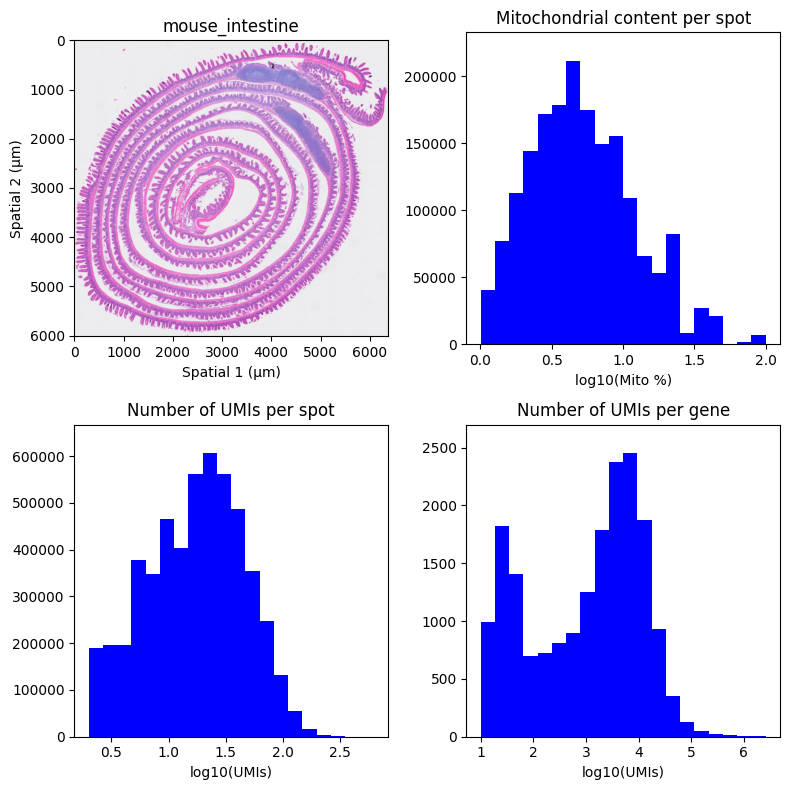

In [2]:
path_image_fullres = r"outs\Visium_HD_Mouse_Small_Intestine_tissue_image.btf"
path_input_data = r"outs\binned_outputs\square_002um"
path_output = r"output"
properties = {"organism":"mouse",
              "organ":"Small intestine",
              "cancer": False,
              "source":"10X"}
si = HiVis.new(path_image_fullres, 
               path_input_data, 
               path_output,
               name="mouse_intestine",  
               properties=properties) # There are also filtering options, see documentation

We now have a HiVis object, which stores the images, anndata and enables plotting and basic analysis

In [3]:
si 

# mouse_intestine #
	Organism: mouse
	Size: 5367189 x 18612

obs: in_tissue, array_row, array_col, pxl_row_in_fullres, pxl_col_in_fullres, pxl_col_in_lowres, pxl_row_in_lowres, pxl_col_in_highres, pxl_row_in_highres, um_x, um_y, nUMI, mito_sum, nUMI_log10, mito_percent_log10

var: gene_ids, feature_types, genome, nUMI_gene, nUMI_gene_log10

*******************************************************

There are additional attributes we can access in HiVis.

In [4]:
si.adata

AnnData object with n_obs × n_vars = 5367189 × 18612
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'pxl_col_in_lowres', 'pxl_row_in_lowres', 'pxl_col_in_highres', 'pxl_row_in_highres', 'um_x', 'um_y', 'nUMI', 'mito_sum', 'nUMI_log10', 'mito_percent_log10'
    var: 'gene_ids', 'feature_types', 'genome', 'nUMI_gene', 'nUMI_gene_log10'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
print(si.name)
print(si.image_fullres.shape) # Also image_highres, image_lowres
print(si.shape) # spots * genes
print(si.path_output)
print(si.properties)

mouse_intestine
(21943, 23304, 3)
(5367189, 18612)
output
{'organism': 'mouse', 'organ': 'Small intestine', 'cancer': False, 'source': '10X'}


*****

Data can easily be acessed through the AnnData or directly

In [6]:
print("nUMI: " + str(si["nUMI"])) # obs
print("nUMI_gene: " + str(si["nUMI_gene_log10"])) # var
gene = "Apob"
print("Apob: " + str(si[gene])) # gene data

nUMI: [ 1. 13.  5. ... 16. 15. 29.]
nUMI_gene: [2.2227166 1.3222193 3.0195317 ... 4.1098824 5.3952827 3.8132472]
Apob: [0. 0. 0. ... 0. 0. 0.]


## Plotting 
Every plot returns matplotlib ax, which can be passed to other plot function and is fully customizible.

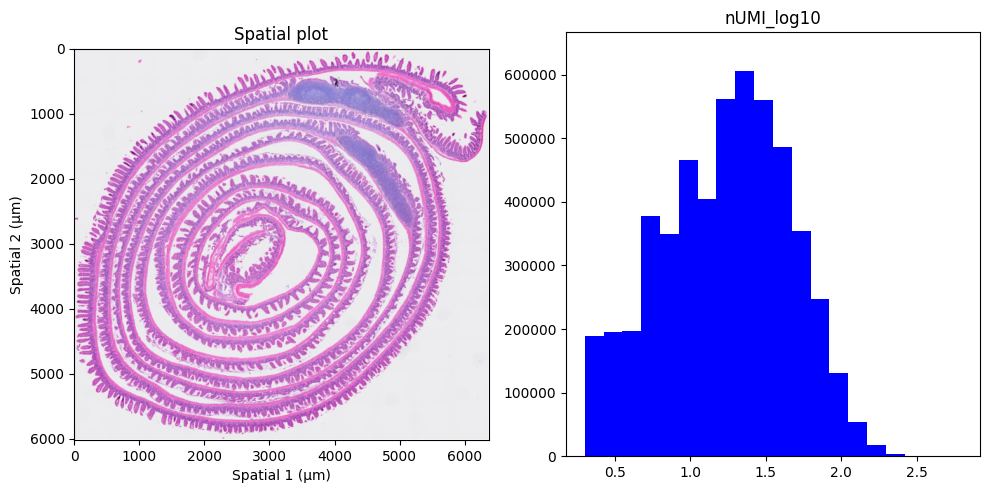

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
si.plot.spatial(ax=axes[0], title="Spatial plot")
si.plot.hist("nUMI_log10", ax=axes[1])
plt.tight_layout()

**** 

Plots have built-in customizations

<Figure size 640x480 with 0 Axes>

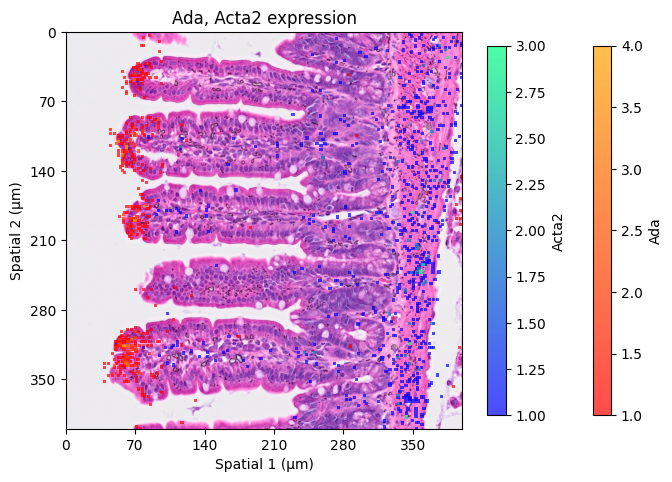

In [8]:
ax = si.plot.spatial("Ada", xlim=[0,400], ylim=[3300,3700], cmap=["red","orange"], alpha=0.7)
ax = si.plot.spatial("Acta2", xlim=[0,400], ylim=[3300,3700], cmap="winter", alpha=0.7, ax=ax, title="Ada, Acta2 expression");

### Saving of plots
We can save plots by passing save=True in the plotting functions. It will be saved in HiVis.path_output that we specified in the beginning.
Alternatively, we can save a figure or ax explicitly.

In [9]:
si.plot.save("Spatial plot of Ada and Acta2", ax=ax)  # or fig=fig, if we created a subplot.

'output/mouse_intestine_Spatial plot of Ada and Acta2.png'

### Work with pixel classifier

A classifier can also be a mask (image with the same dimension as the image that is stored in si.image_fullres).
Detailed instructions for creating a pixel classifier can be found in the readme.

[Importing mask]


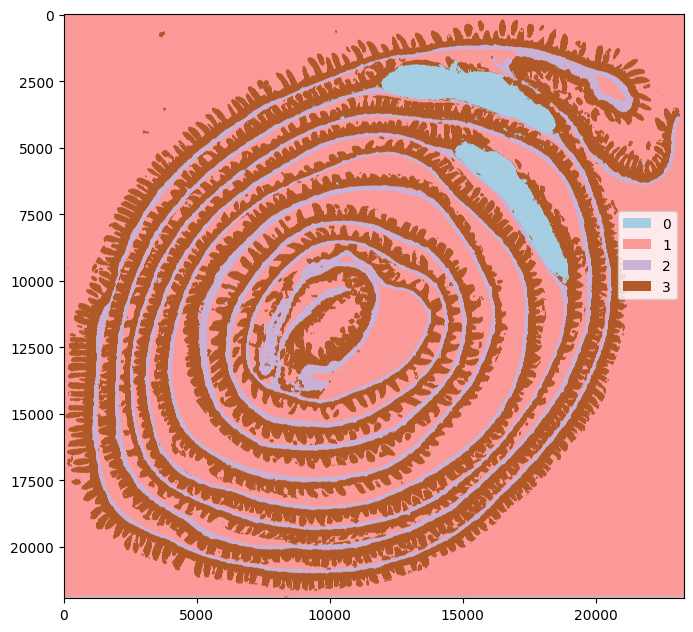

Assigning spots identity [muscle_villi_classifier]: 100%|████████████████| 5367189/5367189 [00:30<00:00, 177127.92it/s]



To rename the values in the metadata, call the [update_meta] method with [muscle_villi_classifier] and dictionary with current_name:new_name


In [10]:
classifier_path = r"qupath\pixel_classifier.tif"
classifier_name = "muscle_villi_classifier"

mask_values = si.add_mask(classifier_path, classifier_name, plot=True)

****

We can now rename the values

In [11]:
values = {0:"immune", 1:"lumen", 2:"muscle", 3:"tissue"}
si.update_meta(classifier_name, values)

And visualize the results

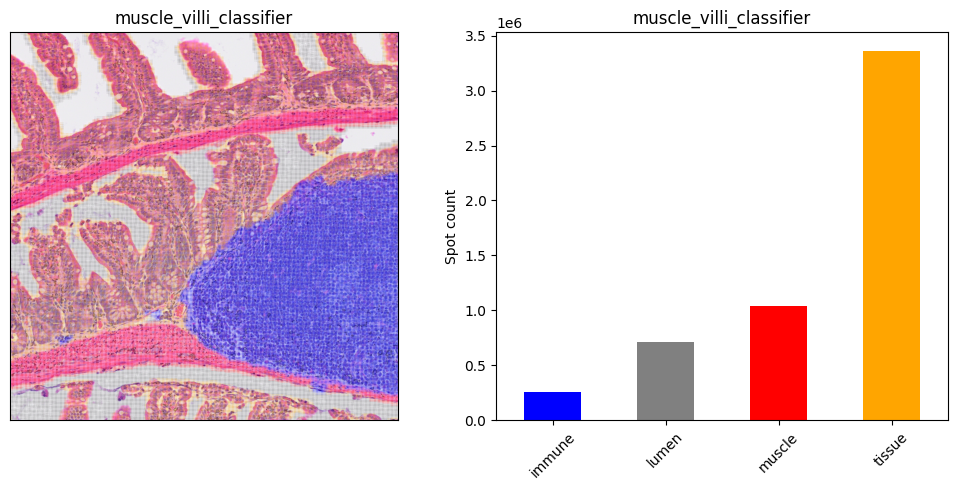

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
colors = {"immune":"blue", "lumen":"gray", "muscle":"red", "tissue":"orange"}
si.plot.spatial("muscle_villi_classifier", xlim=[3000,3600], ylim=[300,900], ax=axes[0], cmap=colors, legend=False, alpha=0.05, axis_labels=False)
si.plot.hist("muscle_villi_classifier", ax=axes[1], cmap=colors, ylab="Spot count")
plt.tight_layout()

### Work with annotations
Annotations can be directly exported from Qupath as geojson

In [13]:
annotation_path = r"qupath\annotation.geojson"
annotation_name = "intestine_part"

mask_values = si.add_annotations(annotation_path, annotation_name)

No measurements found


<Axes: title={'center': 'intestine_part'}, xlabel='Spatial 1 (µm)', ylabel='Spatial 2 (µm)'>

<Figure size 640x480 with 0 Axes>

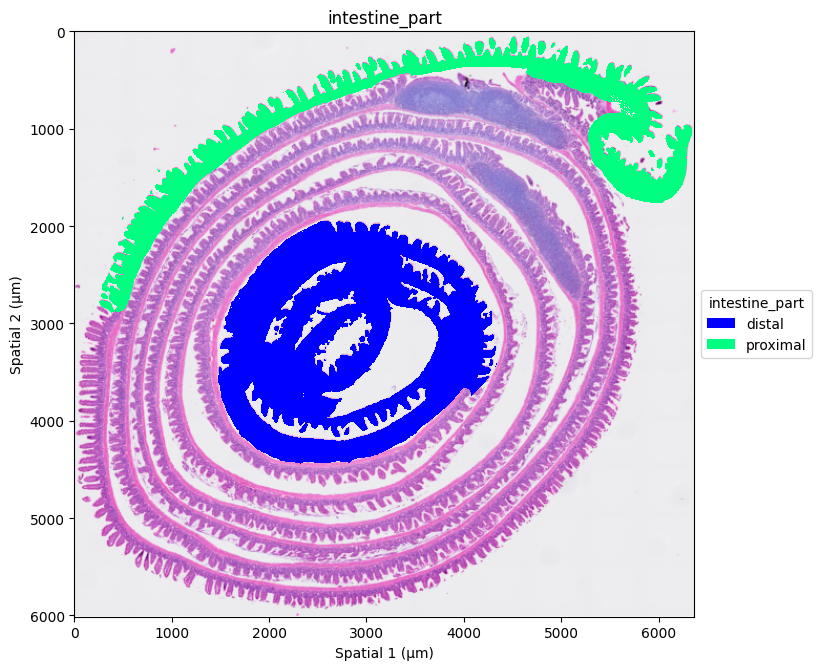

In [14]:
si.plot.spatial(annotation_name)

### Subsetting the HiViz object
We can subset our object based on obs and/or var.

In this example we will subset only genes that are relatively highly expressed.

The subsetting will create a new HiVis object.

In [15]:
high_expressed = si["nUMI_gene"] > 10000
si_subset = si[:, high_expressed]
si_subset.rename("highly_expressed_genes") # otherwise it will be called "subset"

We can also create copies of HiVis objects (not linked to the original object in any way). 

In [17]:
si_copy = si_subset.copy(new_name="copy")
si_copy.name

'mouse_intestine_highly_expressed_genes_copy'

# Compare groups 
Comparison can be performed on classifiers, annotations, and any categorical column in the observations.
## Pseudo-bulk
If we are just interested in the expression levels of each group, we can simply perform pseudobulk.

In [18]:
pb = si_subset.pseudobulk(annotation_name)
pb.head()

,proximal,distal
Lypla1,0.004473,0.003505
Tcea1,0.002382,0.002649
Atp6v1h,0.002556,0.003265
Cops5,0.001933,0.002128
Arfgef1,0.005323,0.006352


### Differential gene expression
If we are interested in actual statistical test we can perform a DGE analysis.

In our example the annotations are large, so the analysis takes few minutes.

In [19]:
proximal_distal = si_subset.dge(annotation_name, group1="proximal", group2="distal")
proximal_distal.head()

Normalizing "proximal" spots
Normalizing "distal" spots
Number of entries in "proximal": 498808, in "distal": 1000037


Running wilcox on [intestine_part]: 100%|██████████████████████████████████████████| 3222/3222 [05:20<00:00, 10.04it/s]


,log2fc,proximal,distal,pval_proximal,pval_distal,pval,qval,expression_mean,expression_min,expression_max,gene
Lypla1,0.332722,0.000201,0.000157,1.000000e+00,2.912348e-19,2.912348e-19,1.039157e-18,0.000179,0.000157,0.000201,Lypla1
Tcea1,-0.106589,0.000131,0.000142,9.408197e-04,9.990592e-01,9.408197e-04,1.399502e-03,0.000136,0.000131,0.000142,Tcea1
Atp6v1h,-0.173911,0.000137,0.000157,6.050715e-14,1.000000e+00,6.050715e-14,1.847906e-13,0.000147,0.000137,0.000157,Atp6v1h
Cops5,0.059409,0.000114,0.000109,5.822384e-03,9.941776e-01,5.822384e-03,7.979465e-03,0.000112,0.000109,0.000114,Cops5
Arfgef1,-0.160877,0.000259,0.000290,4.662937e-15,1.000000e+00,4.662937e-15,1.512989e-14,0.000274,0.000259,0.000290,Arfgef1


We can explore the results, look at top differentially expressed genes

In [20]:
proximal_distal.loc[(proximal_distal["qval"] == 0) & (abs(proximal_distal["log2fc"]) > 4)]

,log2fc,proximal,distal,pval_proximal,pval_distal,pval,qval,expression_mean,expression_min,expression_max,gene
Lct,5.667436,0.000930,0.000006,1.0,0.0,0.0,0.0,0.000468,0.000006,0.000930,Lct
Saa1,-4.546364,0.000015,0.000620,0.0,1.0,0.0,0.0,0.000318,0.000015,0.000620,Saa1
Apoa4,4.460378,0.002453,0.000100,1.0,0.0,0.0,0.0,0.001276,0.000100,0.002453,Apoa4
Enpp7,4.694431,0.001064,0.000029,1.0,0.0,0.0,0.0,0.000547,0.000029,0.001064,Enpp7


<Figure size 640x480 with 0 Axes>

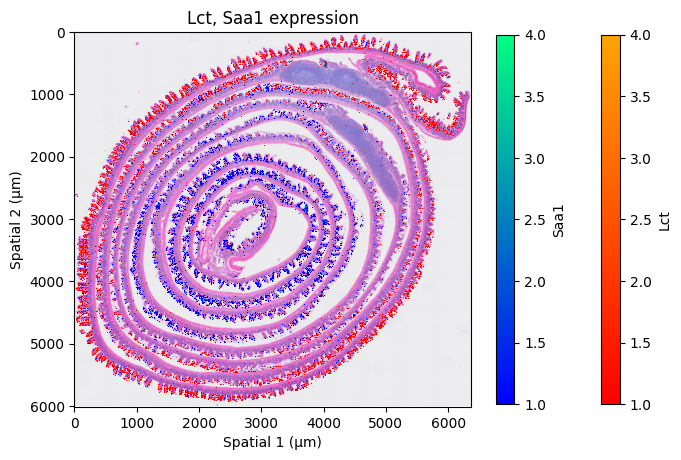

In [21]:
ax = si_subset.plot.spatial("Lct", cmap=["red","orange"])
ax = si_subset.plot.spatial("Saa1", cmap="winter", ax=ax, title="Lct, Saa1 expression")

## Work with single-cells and other structures
We can aggregate the spots into single-cells or single-nuclei.

In this example, the segmentation is performed in Qupath via Stardist with expansion of nuclei.

Tutorial for the segmentation can be seen in the readme file.

In [22]:
segmentation_path = "qupath/stardist_results.csv"
segmentation = pd.read_csv(segmentation_path, sep="\t")
segmentation.rename(columns={"InCell":"in_cell", "InNuc":'in_nucleus',"Object ID":"Cell_ID"}, inplace=True)

C:\Users\royno.WISMAIN\AppData\Local\Temp\ipykernel_34624\2306091075.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  segmentation = pd.read_csv(segmentation_path, sep="\t")


The aggregation by single cells is much faster then performing a pseudobulk on object.
In this case, the aggregation takes few minutes.
Notice that we can add measurements from qupath (color intensity, diameter of cells etc.) to to HiVis adata, and also aggregate metadata from the HiVis.
In this example, we will transfer the annotations and the classifier.

In [23]:
si_subset.agg_stardist(segmentation, name="SC", obs2add=["Area µm^2","Length µm"], obs2agg=["intestine_part","muscle_villi_classifier"])

[Splitting name column and merging metadata]


Aggregating spots expression: 100%|██████████████████████████████████████████| 255071/255071 [01:48<00:00, 2358.98it/s]


We can acess the new Aggregation 

In [24]:
si_subset.agg["SC"]

# Aggregation # mouse_intestine_highly_expressed_genes_SC #

# Parent: mouse_intestine_highly_expressed_genes #
	Size: 255071 x 3222

obs: muscle_villi_classifier, intestine_part, pxl_row_in_fullres, pxl_col_in_fullres, nUMI, spot_count, Area µm^2, Length µm, pxl_col_in_lowres, pxl_row_in_lowres, pxl_col_in_highres, pxl_row_in_highres, um_x, um_y

In [27]:
print(si.name)
print(si.shape) # spots * genes
print(si.path_output)

mouse_intestine
(5367189, 18612)
output


The Aggregation is linked to the HiVis object

In [28]:
si_subset.agg["SC"].viz

# mouse_intestine_highly_expressed_genes #
	Organism: mouse
	Size: 5367189 x 3222

obs: in_tissue, array_row, array_col, pxl_row_in_fullres, pxl_col_in_fullres, nUMI, mito_sum, nUMI_log10, mito_percent_log10, muscle_villi_classifier, intestine_part, intestine_part_id, pxl_col_in_lowres, pxl_row_in_lowres, pxl_col_in_highres, pxl_row_in_highres, um_x, um_y, in_nucleus, in_cell, Cell_ID

var: gene_ids, feature_types, genome, nUMI_gene, nUMI_gene_log10

Aggregations:
[SC]	shape: 255071 x 3222

### Plotting single-cells

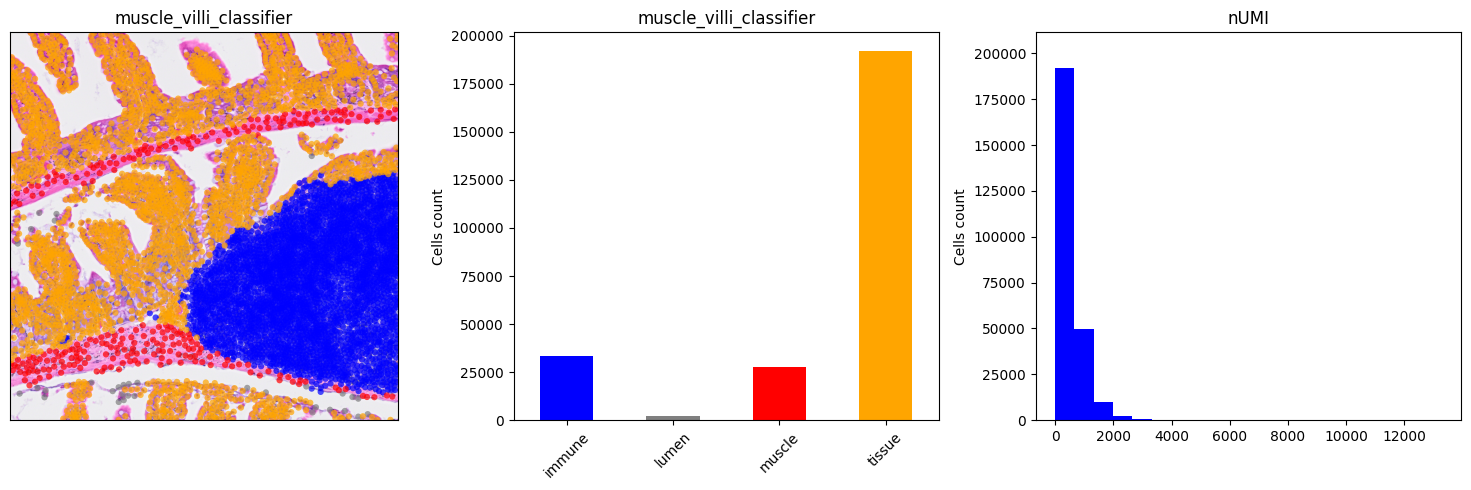

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = {"immune":"blue", "lumen":"gray", "muscle":"red", "tissue":"orange"}
si_subset.agg["SC"].plot.spatial("muscle_villi_classifier", xlim=[3000,3600], ylim=[300,900], ax=axes[0], cmap=colors, legend=False, alpha=0.7, axis_labels=False,size=20)
si_subset.agg["SC"].plot.hist("muscle_villi_classifier", ax=axes[1], cmap=colors, ylab="Cells count")
si_subset.agg["SC"].plot.hist("nUMI", ax=axes[2], ylab="Cells count")
plt.tight_layout()

If we want to visualize the cell boundries, we can import the geometry of the cells (one of the outputs of the Qupath scripts)

In [ ]:
path = r"qupath/geometry.geojson"
si_subset.agg["SC"].import_geometry(path)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.flatten()
cmap = ["darkblue","green","yellow"]
si_subset.agg["SC"].plot.spatial("Apob", xlim=[50,350], ylim=[3320,3520], cmap=cmap, axis_labels=False,size=30, ax=axes[0])
si_subset.agg["SC"].plot.cells("Apob", xlim=[50,350], ylim=[3320,3520], cmap=cmap, axis_labels=False, line_color="black", ax=axes[1])
si_subset.agg["SC"].plot.cells(xlim=[50,350], ylim=[3320,3520], axis_labels=False, line_color="yellow", ax=axes[2])
si_subset.agg["SC"].plot.cells("Apob", image=False, xlim=[50,350], ylim=[3320,3520], cmap=cmap, axis_labels=False, line_color="black", ax=axes[3])
plt.tight_layout()

## Single-cell analysis
Since the data is stored as AnnData, we can work on the adata with other tools, such as [Scanpy](https://scanpy.readthedocs.io/en/stable/) or [Squidpy](https://squidpy.readthedocs.io/en/stable/). If you subset a copy of the adata (for example if you perform UMAP with only highly variable genes, or subset specific cells), you can merge it with the Agg.adata by using Agg.merge().

Be aware of normalization/log transformation of the data, consider working with layers. Plots of Aggregation accept a *layer* argument. If you prefer to

Lets perform basic cell-type clustering and visualize the celltypes with spatial plots. 

For clustering we will use sc.tl.leiden, which requires installation of two packages.

In [32]:
!pip install igraph leidenalg

  Using cached igraph-0.11.8-cp39-abi3-win_amd64.whl.metadata (3.9 kB)
  Using cached leidenalg-0.10.2-cp38-abi3-win_amd64.whl.metadata (10 kB)
  Using cached texttable-1.7.0-py2.py3-none-any.whl.metadata (9.8 kB)
Using cached igraph-0.11.8-cp39-abi3-win_amd64.whl (2.0 MB)
Using cached leidenalg-0.10.2-cp38-abi3-win_amd64.whl (1.6 MB)
Using cached texttable-1.7.0-py2.py3-none-any.whl (10 kB)


C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\demo\Lib\site-packages\scanpy\preprocessing\_normalization.py:235: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


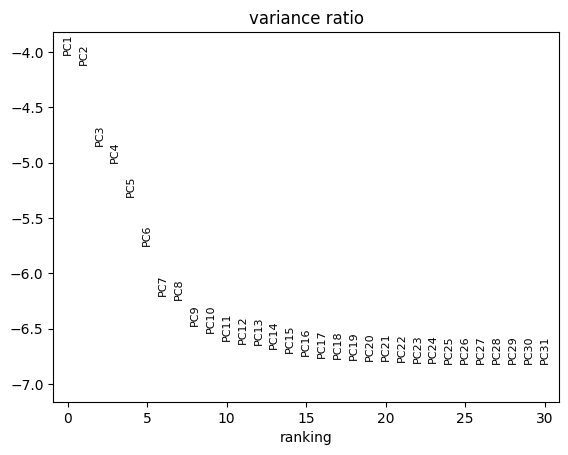

C:\Users\royno.WISMAIN\AppData\Local\Temp\ipykernel_34624\1240710462.py:16: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_sc,resolution=0.7,random_state=0,n_iterations=2,directed=False)


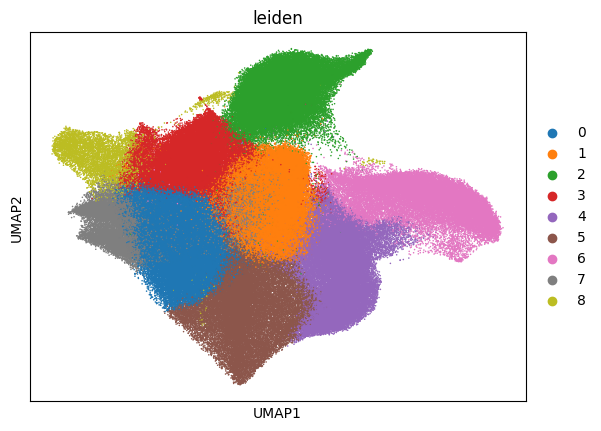

In [35]:
import scanpy as sc

adata_sc = si_subset.agg["SC"].adata.copy()
sc.pp.normalize_total(adata_sc, target_sum=1e4)
adata_sc.var["expression_mean"] = np.array(adata_sc.X.mean(axis=0)).flatten()/1e4
adata_sc.var["expression_max"] =  np.array(adata_sc.X.max(axis=0).toarray()).flatten()/1e4
sc.pp.log1p(adata_sc)
sc.pp.highly_variable_genes(adata_sc, n_top_genes=1000)
adata_sc_full = adata_sc.copy()
adata_sc = adata_sc[:,(adata_sc.var['highly_variable'] == True) ].copy()
sc.pp.scale(adata_sc, max_value=10)
sc.tl.pca(adata_sc, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata_sc, log=True)
sc.pp.neighbors(adata_sc, n_neighbors=15, n_pcs=20) 
sc.tl.umap(adata_sc)
sc.tl.leiden(adata_sc,resolution=0.7,random_state=0,n_iterations=2,directed=False)
sc.pl.umap(adata_sc,color="leiden",size=5)

******
We can merge it to our object

In [45]:
si_subset.agg["SC"].merge(adata_sc,obs="leiden")

In [46]:
si_subset.agg["SC"]["leiden"]


array(['0', '5', '5', ..., '2', '4', '4'], dtype=object)

And plot the clusters

C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\demo\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:1150: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter([], [], c=palette[label], label=label)


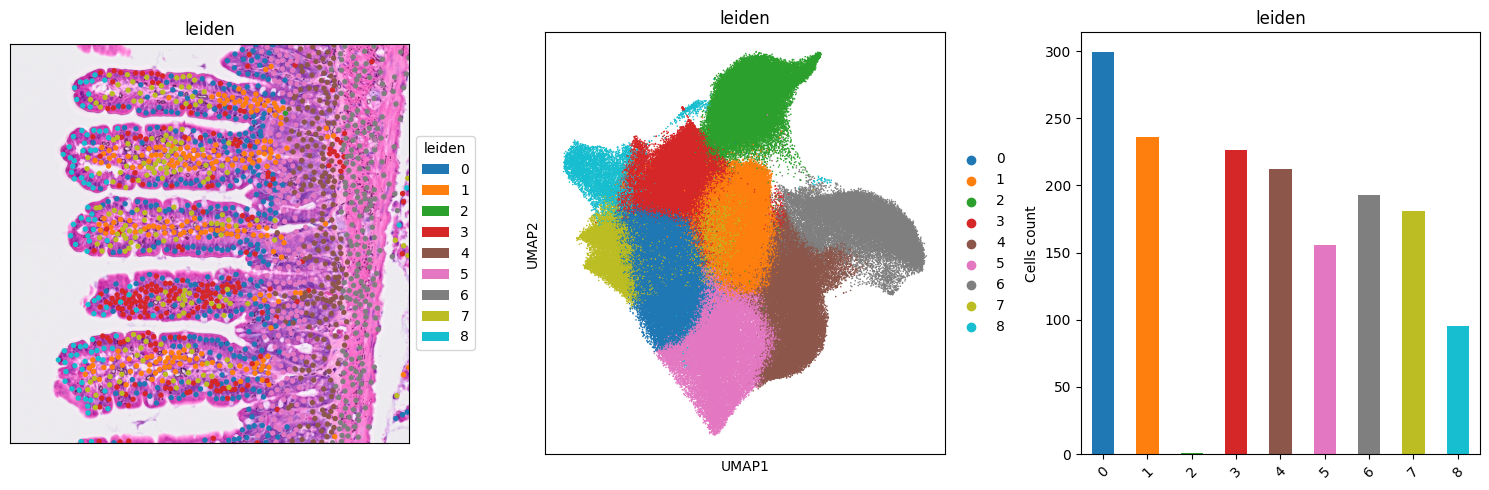

In [47]:
cmap = "tab10"
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
si_subset.agg["SC"].plot.spatial("leiden", xlim=[0,400], ylim=[3300,3700],size=15, ax=axes[0], axis_labels=False,cmap=cmap)
si_subset.agg["SC"].plot.umap("leiden",size=5, ax=axes[1],cmap=cmap)
si_subset.agg["SC"].plot.hist("leiden", ax=axes[2], ylab="Cells count",cmap=cmap,cropped=True)
plt.tight_layout()

Since the Aggregation is linked to the HiVis object, we can transfer information from the Aggregation back to HiVis. Lets transfer the Leiden cluster, so we know the cluster of each spot.

In [48]:
si_subset.agg["SC"].sync("leiden")
si_subset.columns # leiden is added

Index(['in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres',
       'pxl_col_in_fullres', 'nUMI', 'mito_sum', 'nUMI_log10',
       'mito_percent_log10', 'muscle_villi_classifier', 'intestine_part',
       'intestine_part_id', 'pxl_col_in_lowres', 'pxl_row_in_lowres',
       'pxl_col_in_highres', 'pxl_row_in_highres', 'um_x', 'um_y',
       'in_nucleus', 'in_cell', 'Cell_ID', 'leiden'],
      dtype='object')

### Additional anlyses
Like in HiVis, we can perform pseudobulk and DGE on the single-cells

In [56]:
sc_pb = si_subset.agg["SC"].pseudobulk("leiden")
sc_pb.head()

leiden,0,1,2,3,4,5,6,7,8
Lypla1,0.175829,0.044104,0.015537,0.055289,0.026534,0.126466,0.026400,0.110358,0.112993
Tcea1,0.079047,0.037096,0.053060,0.020580,0.044684,0.161981,0.035554,0.046867,0.030154
Atp6v1h,0.112419,0.041665,0.034768,0.029672,0.046932,0.151045,0.045648,0.057309,0.044384
Cops5,0.069819,0.026453,0.024683,0.015389,0.031931,0.145971,0.032570,0.028024,0.019990
Arfgef1,0.230454,0.072160,0.056422,0.073289,0.087793,0.288447,0.052186,0.132621,0.128070


In [57]:
clust1_dge.loc[[clust1_dge['log2fc'].idxmin(), clust1_dge['log2fc'].idxmax()]]

,log2fc,1,rest,pval_1,pval_rest,pval,qval,expression_mean,expression_min,expression_max,gene
Defa21,-3.430935,0.001021,0.011613,0.0,1.0,0.0,0.0,0.006317,0.001021,0.011613,Defa21
Iglc1,4.134377,0.029906,0.001644,1.0,0.0,0.0,0.0,0.015775,0.001644,0.029906,Iglc1


In [60]:
clust1_dge = si_subset.agg["SC"].dge("leiden", group1="1") # we can also ignore group2, and get cluster 1 vs all the rest
clust1_dge.loc[[clust1_dge['log2fc'].idxmin(), clust1_dge['log2fc'].idxmax()]]

Normalizing "1" spots
Normalizing "rest" spots
Number of entries in "1": 41810, in "rest": 213261


Running wilcox on [leiden]: 100%|██████████████████████████████████████████████████| 3222/3222 [00:52<00:00, 61.14it/s]


,log2fc,1,rest,pval_1,pval_rest,pval,qval,expression_mean,expression_min,expression_max,gene
Defa21,-3.430935,0.001021,0.011613,0.0,1.0,0.0,0.0,0.006317,0.001021,0.011613,Defa21
Iglc1,4.134377,0.029906,0.001644,1.0,0.0,0.0,0.0,0.015775,0.001644,0.029906,Iglc1


We can look at the results

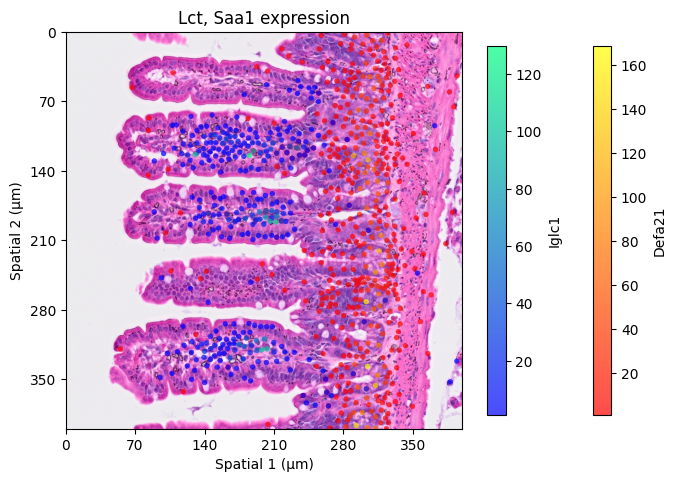

In [59]:
ax = si_subset.agg["SC"].plot.spatial("Defa21", cmap=["red","yellow"], xlim=[0,400], ylim=[3300,3700],alpha=0.7,size=15)
ax = si_subset.agg["SC"].plot.spatial("Iglc1", cmap="winter", ax=ax, title="Lct, Saa1 expression", xlim=[0,400], ylim=[3300,3700],size=15,alpha=0.7,image=False)

### Correlation analysis
We can investigate correlation between genes. One vs all or between a list of genes.

In [61]:
cor_ada = si_subset.agg["SC"].cor("Iglc1")
cor_ada.head()

Computing correlation with Iglc1: 100%|████████████████████████████████████████████| 3222/3222 [00:58<00:00, 55.03it/s]


,r,expression_mean,gene,pval,qval
0,0.004625,0.000173,Lypla1,0.019489,0.029398
1,0.004503,0.000182,Tcea1,0.022950,0.034092
2,0.001614,0.000181,Atp6v1h,0.414892,0.469046
3,-0.006651,0.000130,Cops5,0.000781,0.001439
4,-0.002280,0.000336,Arfgef1,0.249425,0.301670


In [62]:
genes = ["Iglc1","Ang4","Defa21","Igkc","Jchain","Apoe","Anpep","Apoa1","Sis","Igha","Lyz1","Itln1","Apob"]
cor_matrix = si_subset.agg["SC"].cor(genes)
cor_matrix

,Iglc1,Ang4,Defa21,Igkc,Jchain,Apoe,Anpep,Apoa1,Sis,Igha,Lyz1,Itln1,Apob
Iglc1,1.000000,-0.110255,-0.133086,0.284410,0.404299,0.137795,-0.050977,-0.033597,-0.025855,0.398142,-0.132497,-0.128198,-0.054042
Ang4,-0.110255,1.000000,0.597823,-0.104585,-0.056483,0.011542,-0.251921,-0.251746,-0.182767,-0.065821,0.573133,0.575570,-0.131613
Defa21,-0.133086,0.597823,1.000000,-0.126436,-0.067295,0.008278,-0.298577,-0.296741,-0.209477,-0.064792,0.623073,0.608816,-0.152072
Igkc,0.284410,-0.104585,-0.126436,1.000000,0.410232,0.198088,-0.282202,-0.279501,-0.189075,0.412067,-0.121738,-0.122710,-0.194978
Jchain,0.404299,-0.056483,-0.067295,0.410232,1.000000,0.160367,-0.104996,-0.092500,-0.066371,0.477257,-0.070752,-0.066700,-0.088946
Apoe,0.137795,0.011542,0.008278,0.198088,0.160367,1.000000,-0.207038,-0.164175,-0.177378,0.154860,0.016822,0.006358,-0.132708
Anpep,-0.050977,-0.251921,-0.298577,-0.282202,-0.104996,-0.207038,1.000000,0.649079,0.541731,-0.131530,-0.299979,-0.277399,0.426453
Apoa1,-0.033597,-0.251746,-0.296741,-0.279501,-0.092500,-0.164175,0.649079,1.000000,0.451830,-0.130107,-0.297321,-0.278498,0.449929
Sis,-0.025855,-0.182767,-0.209477,-0.189075,-0.066371,-0.177378,0.541731,0.451830,1.000000,-0.076020,-0.207771,-0.188870,0.336144
Igha,0.398142,-0.065821,-0.064792,0.412067,0.477257,0.154860,-0.131530,-0.130107,-0.076020,1.000000,-0.066730,-0.061656,-0.113782


And we can plot correlations

Computing correlation with Iglc1: 100%|████████████████████████████████████████████| 3222/3222 [01:04<00:00, 49.74it/s]


                  r  expression_mean  qval
Igha       0.497969         0.018159   0.0
Jchain     0.496516         0.003368   0.0
Igkc       0.437695         0.023645   0.0
Igfbp3     0.211089         0.000365   0.0
Adamdec1   0.198909         0.000917   0.0
Apoe       0.184951         0.002463   0.0
Trp53inp1  0.173840         0.000255   0.0
Igkv4-72   0.166331         0.000159   0.0
Mzb1       0.162718         0.000200   0.0
Tmem176b   0.135929         0.000670   0.0


<Axes: title={'center': 'Iglc1'}, xlabel='log10(mean expression)', ylabel='Spearman correlation'>

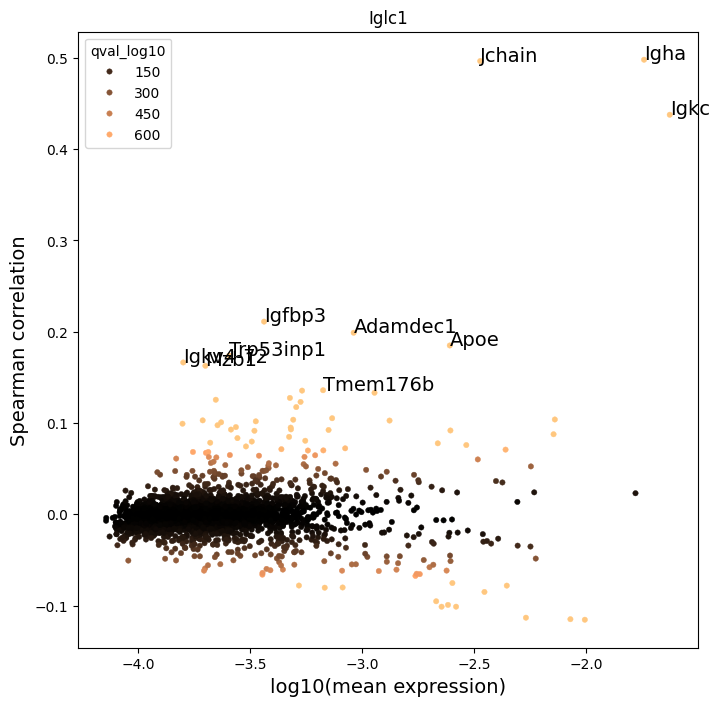

In [63]:
si_subset.agg["SC"].plot.cor("Iglc1", number_of_genes=10, cmap="copper") # can also plot genes we haven't calculated before

<Axes: >

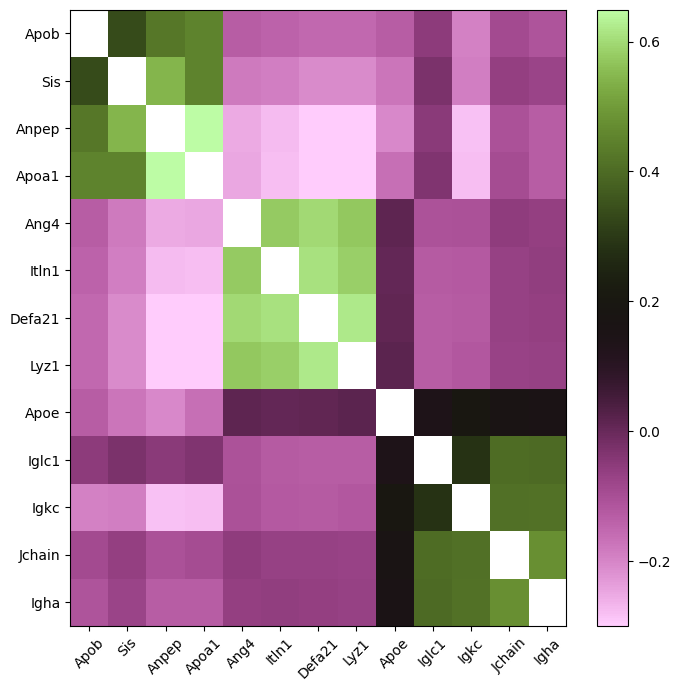

In [64]:
si_subset.agg["SC"].plot.cor(genes, cmap="vanimo", cluster=True)

### Noise mean curve
With this analysis we can find genes with high variabilty in the data.

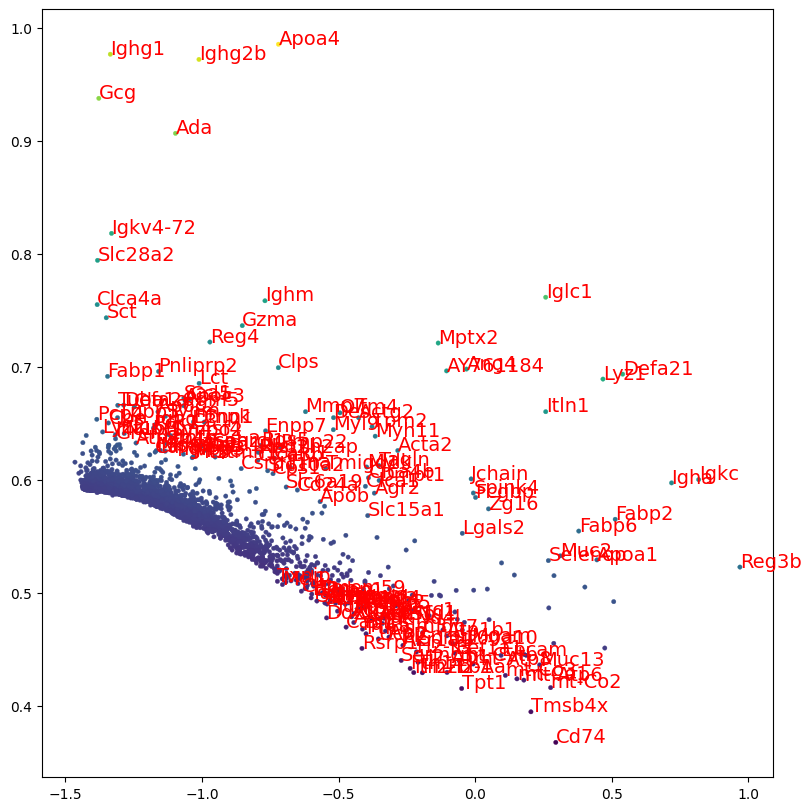

In [65]:
noise_genes, ax = si_subset.agg["SC"].noise_mean_curve(plot=True)

### Cropping the data
Similar to subsetting HiVis, we can crop/subset Aggregation.

Notice that cropping HiVis will also autimatically crop the Aggregations. 

In [66]:
cluster_0 = si_subset.agg["SC"]["leiden"] == "0"
si_subset.agg["cluster_0"] = si_subset.agg["SC"][cluster_0,:]
si_subset.agg["cluster_0"].rename("mouse_intestine_SC_clust0", full=True, new_out_path=True)

### Copying the Agg object
We can copy the Aggregation object, similar to the HiVis. You can rename the new copy. Notice that the new object will be linked to the HiVis parent object.

In [67]:
si_subset.agg["SC_copy"] = si_subset.agg["SC"].copy(new_name="copy")

## Saving your work
To avoid running the analysis every time, you can save the HiVis object, together with the Aggregations.

In [ ]:
path = si_subset.save()
path

And we can load it back, after importing the dependencies

In [ ]:
si_subset = HiVis.load(path)